In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [4]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [5]:
df.isnull().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


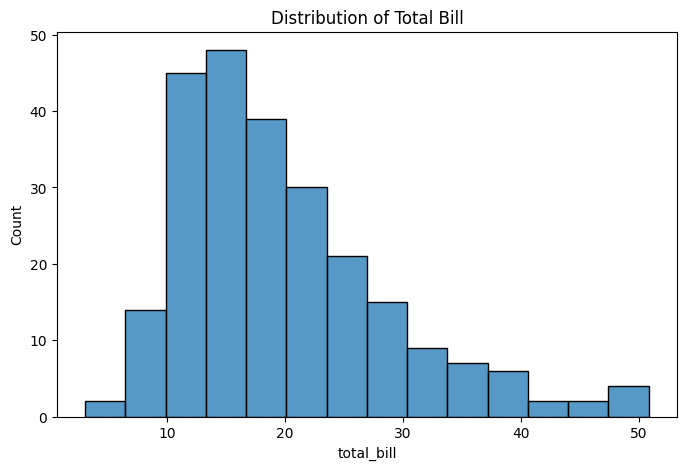

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['total_bill'])
plt.title('Distribution of Total Bill')
plt.show()

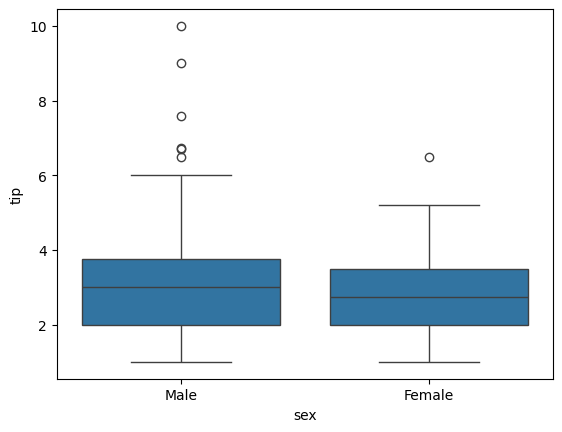

In [7]:
sns.boxplot(x='sex', y='tip', data=df)
plt.show()

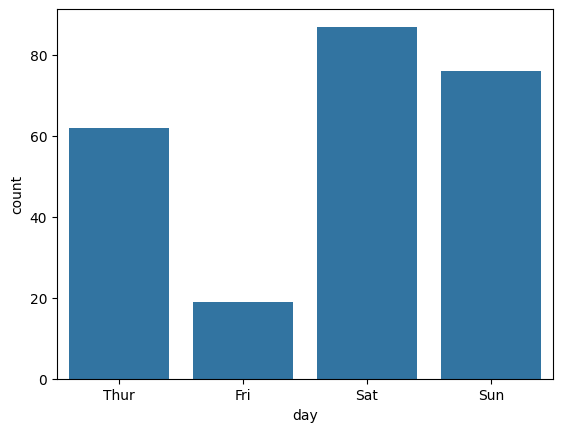

In [8]:
sns.countplot(x='day', data=df)
plt.show()

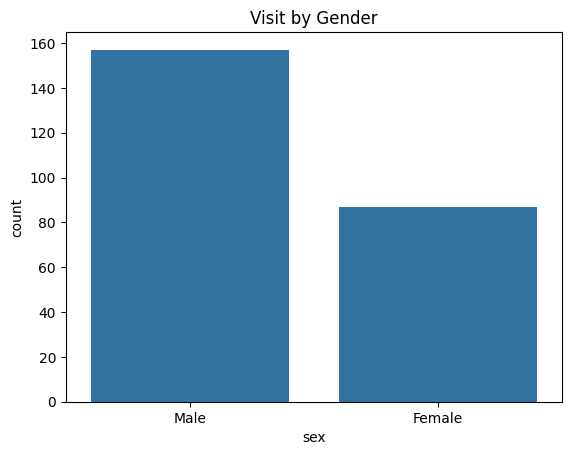

In [9]:
#visits by gender
sns.countplot(x='sex', data=df)
plt.title('Visit by Gender')
plt.show()

In [10]:
sns.heatmap(df.corr(), annot=True, cmap='Blues')
plt.title('Correlation Matrix')
plt.show()

ValueError: could not convert string to float: 'No'

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [12]:
df2 = df.select_dtypes(include='number')
df2

,total_bill,tip,size
0,16.99,1.01,2
1,10.34,1.66,3
2,21.01,3.50,3
3,23.68,3.31,2
4,24.59,3.61,4
...,...,...,...
239,29.03,5.92,3
240,27.18,2.00,2
241,22.67,2.00,2
242,17.82,1.75,2


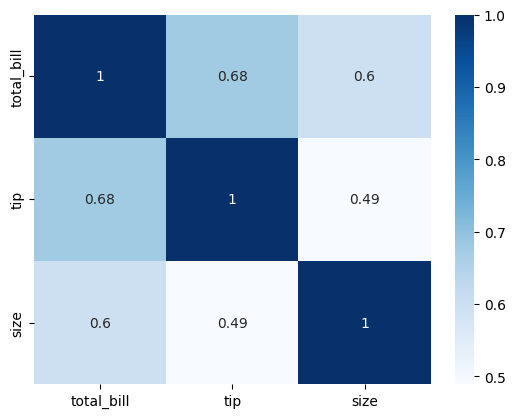

In [13]:
sns.heatmap(df2.corr(), annot=True, cmap='Blues')
plt.show()

In [14]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [15]:
df['tip_percentage'] = (df['tip'] / df['total_bill']) * 100
df.head()

,total_bill,tip,sex,smoker,day,time,size,tip_percentage
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765


In [16]:
df['percent'] = df['tip_percentage'].round(2).astype(str) + '%'
df.head()

,total_bill,tip,sex,smoker,day,time,size,tip_percentage,percent
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673,5.94%
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159,16.05%
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734,16.66%
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041,13.98%
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765,14.68%


<Axes: xlabel='day', ylabel='tip_percentage'>

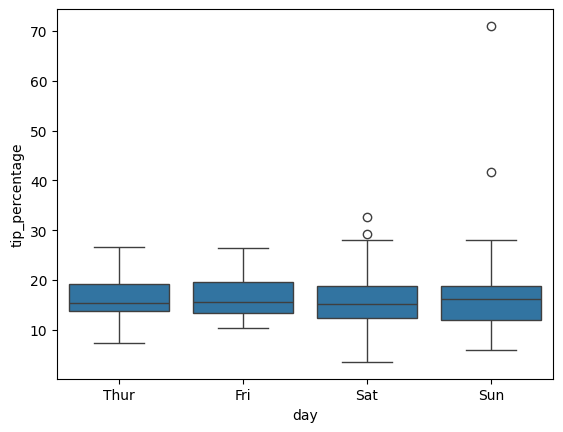

In [17]:
sns.boxplot(x='day', y='tip_percentage', data=df)

In [19]:
df.groupby('smoker')['tip_percentage'].mean()

/tmp/ipykernel_3783/3494168819.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('smoker')['tip_percentage'].mean()


,tip_percentage
smoker,
Yes,16.319604
No,15.932846


In [20]:
df.groupby('smoker')['tip_percentage'].max()

/tmp/ipykernel_3783/3227751129.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('smoker')['tip_percentage'].max()


,tip_percentage
smoker,
Yes,71.034483
No,29.198966


In [21]:
df.groupby('time')['total_bill'].mean()

/tmp/ipykernel_3783/1690409114.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('time')['total_bill'].mean()


,total_bill
time,
Lunch,17.168676
Dinner,20.797159


In [23]:
df.groupby('time')['total_bill'].max()

/tmp/ipykernel_3783/2011320423.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('time')['total_bill'].max()


,total_bill
time,
Lunch,43.11
Dinner,50.81


<Axes: xlabel='total_bill', ylabel='tip'>

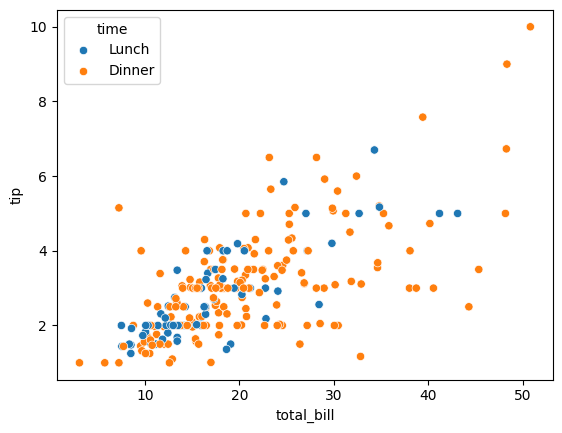

In [24]:
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time')

In [ ]:
# Find which day has the highest average bill
# Compare tips percentage between lunch and dinner